# GSE152075 differential expression (SARS-CoV-2 pos vs neg)

This cleaned notebook keeps only the steps needed to:
1. Load the raw count matrix
2. Build sample metadata from the GEO series matrix
3. Align counts and metadata
4. Filter low-count genes
5. Run differential expression with **pyDESeq2**
6. Create basic QC and result plots (volcano, PCA, heatmap)


In [1]:
# Core imports
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# ------------------------------
# 1) Load raw counts
# ------------------------------
# Expectation: rows = genes, columns = samples (e.g., POS_001, NEG_001, ...)

COUNTS_FILE = "GSE152075_raw_counts_GEO.txt"

# Most GEO tables are tab-separated; some exports are whitespace-separated.
# Use ONE of these depending on your file format.
# try:
#     counts_df = pd.read_csv(COUNTS_FILE, sep='\t', header=0, index_col=0)
# except Exception:
counts_df = pd.read_csv(COUNTS_FILE, sep=r'\s+', header=0, index_col=0)

# pyDESeq2 expects integer counts
counts_df = (
    counts_df.apply(pd.to_numeric, errors='coerce')
            .fillna(0)
            .astype(int)
)

print('Genes:', counts_df.shape[0])
print('Samples:', counts_df.shape[1])
counts_df.columns[:10]


Genes: 35784
Samples: 484


Index(['POS_001', 'POS_002', 'POS_003', 'POS_004', 'POS_005', 'POS_006',
       'POS_007', 'POS_008', 'POS_009', 'POS_010'],
      dtype='object')

In [4]:
# ---------------------------------------------
# 2) Build metadata from the GEO series matrix
# ---------------------------------------------
# We parse !Sample_title and !Sample_characteristics_ch1 rows to extract:
# - condition (pos/neg -> covid/control)
# - sequencing batch
# - optional covariates (age, gender, N1 Ct)

SERIES_MATRIX = "GSE152075_series_matrix.txt"

with open(SERIES_MATRIX, 'r', errors='replace') as f:
    lines = f.readlines()

def get_field_values(field_name: str):
    """Return the tab-separated values for a GEO series-matrix field."""
    for line in lines:
        if line.startswith(field_name + '\t'):
            vals = line.strip().split('\t')[1:]
            return [v.strip().strip('\"') for v in vals]
    return None

# The sample titles typically match the column names in the raw count matrix
sample_titles = get_field_values('!Sample_title')
if sample_titles is None:
    raise ValueError('Could not find !Sample_title in series matrix')

# Collect all characteristics rows (multiple rows; one value per sample per row)
char_lines = [ln for ln in lines if ln.startswith('!Sample_characteristics_ch1\t')]
char_rows = []
for ln in char_lines:
    vals = [v.strip().strip('\"') for v in ln.strip().split('\t')[1:]]
    char_rows.append(vals)
char_rows = np.array(char_rows, dtype=object)  # shape: (n_rows, n_samples)

meta = pd.DataFrame(index=sample_titles)
meta.index.name = 'sample'

# One blob per sample -> simple regex extraction
char_blob = pd.Series(
    [' | '.join(char_rows[:, i].astype(str)) for i in range(char_rows.shape[1])],
    index=meta.index
)

def to_numeric_clean(x: pd.Series) -> pd.Series:
    """Convert a messy numeric field (Unknown, N/A, 90+) to floats."""
    x = x.astype(str).str.strip()
    x = x.replace({'Unknown': np.nan, 'N/A': np.nan})
    x = x.str.replace(r'\+$', '', regex=True)  # 90+ -> 90
    return pd.to_numeric(x, errors='coerce')

# Extract fields (adjust regex if your series matrix uses different keys)
meta['positivity'] = char_blob.str.extract(r'sars-cov-2 positivity:\s*([a-z]+)', expand=False)
meta['n1_ct']      = char_blob.str.extract(r'n1_ct:\s*([0-9.]+|Unknown|N/A)', expand=False)
meta['age']        = char_blob.str.extract(r'age:\s*([0-9+]+|Unknown)', expand=False)
meta['gender']     = char_blob.str.extract(r'gender:\s*([MF]|not collected)', expand=False)
meta['batch']      = char_blob.str.extract(r'sequencing_batch:\s*([A-Z])', expand=False)

# Clean / type conversion
meta['condition'] = meta['positivity'].map({'pos': 'covid', 'neg': 'control'})
meta['n1_ct'] = to_numeric_clean(meta['n1_ct'])
meta['age']   = to_numeric_clean(meta['age'])
meta['gender'] = meta['gender'].replace({'not collected': np.nan})

# Categoricals are recommended for design factors
meta['condition'] = meta['condition'].astype('category')
meta['gender']    = meta['gender'].astype('category')
meta['batch']     = meta['batch'].astype('category')

# Keep only samples that have a condition label
meta = meta.dropna(subset=['condition']).copy()

meta.head()


,positivity,n1_ct,age,gender,batch,condition
sample,,,,,,
POS_001,pos,18.88,64.0,M,I,covid
POS_002,pos,21.18,30.0,F,I,covid
POS_003,pos,24.24,47.0,M,I,covid
POS_004,pos,18.91,67.0,F,G,covid
POS_005,pos,25.62,62.0,M,H,covid


In [5]:
# --------------------------------
# 3) Align counts and metadata
# --------------------------------
# Ensure we analyze exactly the intersection of samples present in both files.

meta = meta.loc[meta.index.intersection(counts_df.columns)].copy()
counts = counts_df.loc[:, meta.index].copy()

print('Counts:', counts.shape)
print('Metadata:', meta.shape)
print(meta['condition'].value_counts())

# Quick check: are conditions balanced within batches?
ct = pd.crosstab(meta['batch'], meta['condition'])
display(ct)
display(((ct.T / ct.sum(axis=1)).T).round(3))


Counts: (35784, 484)
Metadata: (484, 6)
condition
covid      430
control     54
Name: count, dtype: int64


condition,control,covid
batch,,
A,0,19
B,0,15
C,1,16
D,0,14
E,0,23
F,0,24
G,0,16
H,0,21
I,0,15


condition,control,covid
batch,,
A,0.000,1.000
B,0.000,1.000
C,0.059,0.941
D,0.000,1.000
E,0.000,1.000
F,0.000,1.000
G,0.000,1.000
H,0.000,1.000
I,0.000,1.000


In [6]:
# --------------------------------
# 4) Filter very low-count genes
# --------------------------------
# A simple and common filter: keep genes with total count >= 10 across samples.

keep = counts.sum(axis=1) >= 10
counts_filt = counts.loc[keep].copy()
print('Filtered counts shape:', counts_filt.shape)


Filtered counts shape: (28143, 484)


In [7]:
# --------------------------------
# 5) Differential expression (pyDESeq2)
# --------------------------------
# IMPORTANT: pydeseq2 expects counts as a DataFrame with samples as rows.
# We'll use a design that adjusts for batch if available.

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

design = '~ batch + condition' if meta['batch'].notna().any() else '~ condition'
print('Design:', design)

dds = DeseqDataSet(
    counts=counts_filt.T,
    metadata=meta,
    design=design,
    refit_cooks=True,
)
dds.deseq2()

stats = DeseqStats(dds, contrast=('condition', 'covid', 'control'))
stats.summary()
res_df = stats.results_df.sort_values('padj')

print('DEGs padj<0.05:', (res_df['padj'] < 0.05).sum())
res_df.head()


Design: ~ batch + condition
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.64 seconds.

Fitting dispersions...
... done in 5.19 seconds.

Fitting dispersion trend curve...
... done in 0.47 seconds.

Fitting MAP dispersions...
... done in 5.00 seconds.

Fitting LFCs...
... done in 14.13 seconds.

Calculating cook's distance...
... done in 0.68 seconds.

Replacing 2262 outlier genes.

Fitting dispersions...
... done in 0.45 seconds.

Fitting MAP dispersions...
... done in 0.44 seconds.

Fitting LFCs...
... done in 2.03 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition covid vs control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG     9.793909        0.643102  1.014812  0.633716  0.526266       NaN
A1CF     2.353146        0.427712  1.542631  0.277261  0.781580       NaN
A2M     50.487225        0.003113  0.621260  0.005011  0.996002  0.997541
A2ML1    5.588551       -0.182230  1.110407 -0.164111  0.869644       NaN
A2MP1    1.317577        0.353406  2.063836  0.171237  0.864037       NaN
...           ...             ...       ...       ...       ...       ...
ZXDC    15.423872       -0.719185  0.690807 -1.041080  0.297838       NaN
ZYG11A   3.213120       -1.048628  1.272547 -0.824039  0.409918       NaN
ZYG11B  30.271790       -0.828654  0.566537 -1.462664  0.143559       NaN
ZYX     27.597552        0.212603  0.634397  0.335126  0.737530       NaN
ZZEF1   55.321901       -0.251826  0.543861 -0.463034  0.643340  0.816924

[28143 rows x 6 columns]
DEGs padj<0.05: 42


... done in 1.35 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MTRNR2L12,409286.937120,0.607438,0.110597,5.492352,3.966151e-08,0.000099
CXCL10,197.054057,4.476797,0.861343,5.197461,2.020290e-07,0.000252
GBP5,212.874119,3.268915,0.648878,5.037796,4.709234e-07,0.000392
IFIT3,451.254159,2.931350,0.588544,4.980679,6.336166e-07,0.000396
IFIT2,585.751666,3.163161,0.643684,4.914156,8.916582e-07,0.000446


In [ ]:
# Save results for downstream use
res_df.to_csv('deseq2_results_POS_vs_NEG.csv')
meta.to_csv('metadata_POS_vs_NEG.csv')


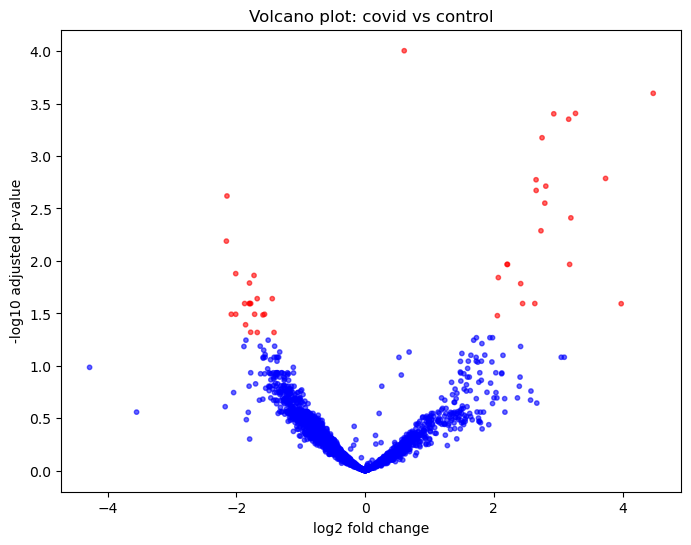

In [8]:
# --------------------------------
# 6) Volcano plot
# --------------------------------
# Note: -log10(padj) is undefined for padj==0, so we clip.

plot_df = res_df.copy()
plot_df['padj_clipped'] = plot_df['padj'].clip(lower=1e-300)

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df['log2FoldChange'],
    -np.log10(plot_df['padj_clipped']),
    c=(plot_df['padj'] < 0.05),
    cmap='bwr',
    alpha=0.6,
    s=10,
)
plt.xlabel('log2 fold change')
plt.ylabel('-log10 adjusted p-value')
plt.title('Volcano plot: covid vs control')
plt.show()


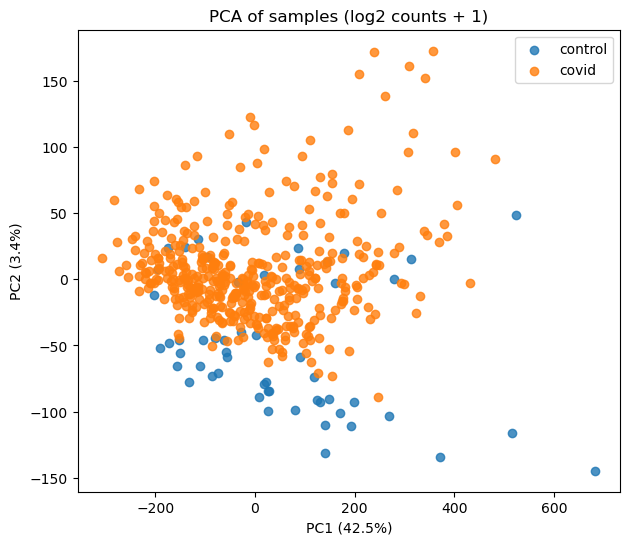

In [9]:
# --------------------------------
# 7) PCA on log-transformed counts
# --------------------------------
from sklearn.decomposition import PCA

log_counts = np.log2(counts_filt + 1).T  # samples x genes
pca = PCA(n_components=2)
pc = pca.fit_transform(log_counts)

plt.figure(figsize=(7, 6))
for cond in meta['condition'].cat.categories:
    idx = (meta['condition'] == cond).to_numpy()
    plt.scatter(pc[idx, 0], pc[idx, 1], label=str(cond), alpha=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA of samples (log2 counts + 1)')
plt.legend()
plt.show()


c:\Users\BVERMA\AppData\Local\miniforge3\envs\learnML\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\BVERMA\AppData\Local\miniforge3\envs\learnML\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


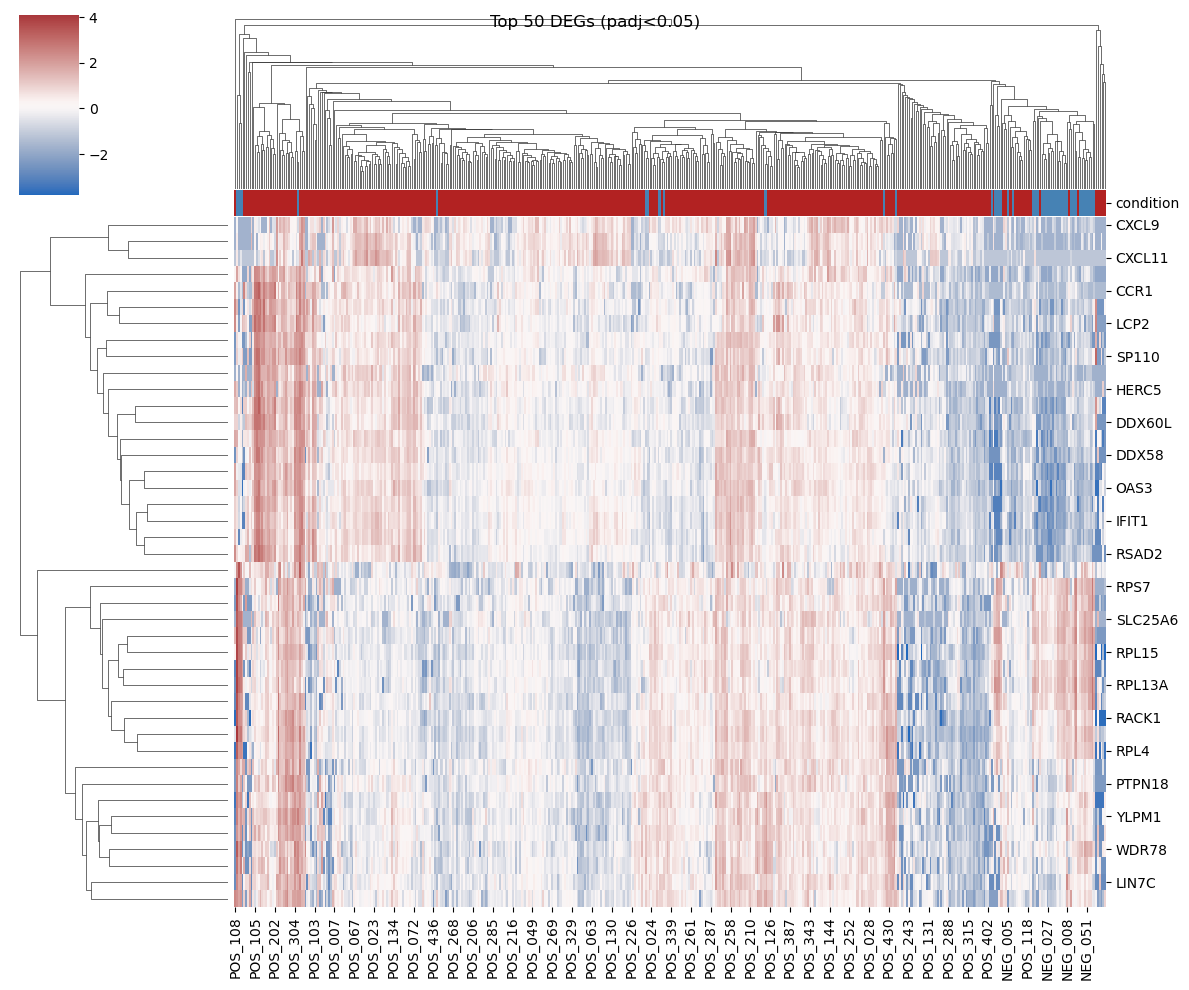

In [10]:
# --------------------------------
# 8) Heatmap of top DE genes
# --------------------------------
sig = res_df[res_df['padj'] < 0.05].copy()
top_genes = sig.head(50).index

top_counts = counts_filt.loc[top_genes]
log_top = np.log2(top_counts + 1)

condition_colors = (
    meta.loc[log_top.columns, 'condition']
    .map({'control': 'steelblue', 'covid': 'firebrick'})
)

sns.clustermap(
    log_top,
    col_colors=condition_colors,
    cmap='vlag',
    z_score=0,
    figsize=(12, 10),
)
plt.suptitle('Top 50 DEGs (padj<0.05)')
plt.show()
